# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Install Required Libraries

In [ ]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [ ]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
# Write code to load the data and check the schema

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Basics').getOrCreate()
collisions_df = spark.read.csv('/content/drive/MyDrive/C3-Cloud_Computing_and_big_data/project_Traffic_Collision/sample_collisions.csv', header=True, inferSchema=True)
collisions_df.show(20, truncate = False)

+-----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+----------------------------------+------------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+---------------------------------+-------------+------------------------+---------------+-----------------+---------------------------+----------------------+------------+----------------+-----------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+---------------------------------------+-------------------+--------------------------+------------------------------+--

In [ ]:
parties_df = spark.read.csv('/content/drive/MyDrive/C3-Cloud_Computing_and_big_data/project_Traffic_Collision/sample_parties.csv', header=True, inferSchema=True)
parties_df.show(5)

+--------+--------------------+------------+----------+--------+---------+---------+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|      id|             case_id|party_number|party_type|at_fault|party_sex|party_age|      party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|  cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+--------+--------------------+------------+----------+--------+---------+---------+--------------------+-------------

In [ ]:
victims_df = spark.read.csv('/content/drive/MyDrive/C3-Cloud_Computing_and_big_data/project_Traffic_Collision/sample_victims.csv', header=True, inferSchema=True)
victims_df.show(20)

+-------+--------------------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|             case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+--------------------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|2166324|           6324923.0|           1|     driver|      male|      62.0|      complaint of pain|                 driver|     air bag not deployed|     lap/shoulder harn...|   not ejected|
| 779470|            761473.0|           1|  passenger|      male|      25.0|              no injury|       passenger seat 3|     lap/shoulder harn...|                     NULL|   not ejected|
| 742636|            723123.0|     

In [ ]:
victims_df.count()

963933

In [ ]:
victims_df.groupBy("id").count().filter("count > 1").count()
victims_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



In [ ]:
caseIds_df = spark.read.csv('/content/drive/MyDrive/C3-Cloud_Computing_and_big_data/project_Traffic_Collision/sample_case_ids.csv', header=True, inferSchema=True)
caseIds_df.show(5)

+-----------+-------+
|    case_id|db_year|
+-----------+-------+
|9.0017156E7|   2021|
|  4078685.0|   2021|
|9.0588783E7|   2021|
|  3351919.0|   2018|
|   632208.0|   2018|
+-----------+-------+
only showing top 5 rows


#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [ ]:
#Display Schema & Sample Data
collisions_df.printSchema()

root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |-- s

In [ ]:
#Row Count
collisions_df.count()

935791

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [ ]:
#Check for Missing Values

from pyspark.sql import functions as F

missing_df = collisions_df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in collisions_df.columns]
)

missing_df.show(truncate=False)

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
#Drop Sparse Columns
# a sparse column is a column that contains a very high proportion of missing values (NULLs) compared to the total number of rows.

total_rows = collisions_df.count()


missing_values_percentage = (
    collisions_df.select([
        F.round((F.count(F.when(F.col(c).isNull(), c)) / total_rows * 100),2)
        .alias(c) for c in collisions_df.columns
    ])
)

missing_values_percentage.show(truncate=False)

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
# caltrans_county - 72.89%
# location_type - 72.89
# side_of_highway - 72.89
# Latitude - 71.5
# Longitude - 71.5

#Missing Data percentage is more than 70%, hence removing the columns
collisions_df_clean = collisions_df.drop("caltrans_county", "location_type", "side_of_highway")
                                         #"Latitude", "Longitude")

revised_col_count = len(collisions_df_clean.columns)
revised_col_count

62

In [ ]:
#Convert Data Types

from pyspark.sql.types import IntegerType, LongType, DoubleType

df_clean_typed = (
    collisions_df_clean

    #Ids
    .withColumn("case_id", F.col("case_id").cast("String"))
    .withColumn("jurisdiction", F.col("jurisdiction").cast(IntegerType()))

    #Count fields
    .withColumn("killed_victims", F.col("killed_victims").cast(IntegerType()))
    .withColumn("injured_victims", F.col("injured_victims").cast(IntegerType()))
    .withColumn("party_count", F.col("party_count").cast(IntegerType()))
    .withColumn("pcf_violation", F.col("pcf_violation").cast(IntegerType()))

    #Flag Fields

    .withColumn("intersection", F.col("intersection").cast(IntegerType()))
    .withColumn("state_highway_indicator", F.col("state_highway_indicator").cast(IntegerType()))
    .withColumn("tow_away", F.col("tow_away").cast(IntegerType()))
    .withColumn("not_private_property", F.col("not_private_property").cast(IntegerType()))
)

In [ ]:
#Verify the schema after converting datatypes
df_clean_typed.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: integer (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: integer (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: integer (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |-- state_route: double (nullable = true)
 |-- po

In [ ]:
#Handle Missing Values

final_df = df_clean_typed.fillna({
    #Categorical
    "control_device": "Unknown",
    "lighting": "Unknown",
    "motor_vehicle_involved_with": "Unknown",
    "pedestrian_action": "Unknown",
    "road_surface": "Unknown",
    "road_condition_1": "Unknown",
    "type_of_collision": "Unknown",
    "weather_1": "Unknown",
    "primary_collision_factor": "Unknown",
    "pcf_violation_category": "Unknown",
    "officer_id": "Unknown_Officer",
    "statewide_vehicle_type_at_fault": "Unknown",
    "chp_vehicle_type_at_fault": "Unknown",
    "pcf_violation_subsection": "Unknown",
    "direction": "Unknown",
    "beat_number": "Unknown",
    "reporting_district": "Unknown",

})

final_df = final_df.fillna({
    #Numeric
    "injured_victims": 0,
    "killed_victims": 0,
    "party_count": 0,
    #Flags
    "intersection": 0,
    "tow_away": 0,
    "state_highway_indicator": 0
})

#pcf Violation
final_df = final_df.withColumn(
    "pcf_violation",
    F.when(F.col("pcf_violation").isNull(), -1)
     .otherwise(F.col("pcf_violation"))
)

final_df = (
    final_df
    .withColumn("caltrans_district",
                F.coalesce(F.col("caltrans_district"), F.lit(-1)))
    .withColumn("state_route",
                F.coalesce(F.col("state_route"), F.lit(-1)))
    .withColumn("jurisdiction",
                F.coalesce(F.col("jurisdiction"), F.lit(-1)))
    .withColumn("postmile",
	              F.coalesce(F.col("postmile"), F.lit(-1.0)))
    .withColumn("special_condition",
	              F.coalesce(F.col("special_condition"), F.lit(-1.0)))

)

#Population being a String
final_df = final_df.fillna({"population": "Unknown"})

In [ ]:
final_df = final_df.filter(
    F.col("chp_beat_class").isNotNull() &
    F.col("primary_road").isNotNull() &
    F.col("secondary_road").isNotNull()
)

In [ ]:
final_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in final_df.columns
]).show(truncate=False)

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+-----------------+-----------+--------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+----

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Duplicates
print("Number of duplicate rows : ", final_df.groupBy("case_id").count().filter("count > 1").count())
#There are 27 duplicates

df_dup = final_df.count()
print("Number of rows before removing duplicates : ", df_dup)

#Dedup
final_df = final_df.dropDuplicates(["case_id"])
print("Number of rows after removing duplicates : ", final_df.count())

Number of duplicate rows :  27
Number of rows before removing duplicates :  935505
Number of rows after removing duplicates :  935478


In [ ]:
# Detect Outliers using IQR

# List of numerical columns to check for outliers

numeric_cols = [

    "distance",
    "party_count",

    # -- Injured Count
    "injured_victims",
    "severe_injury_count",
    "other_visible_injury_count",
    "complaint_of_pain_injury_count",
    "pedestrian_injured_count",
    "bicyclist_injured_count",
    "motorcyclist_injured_count",

    # #-- Fatality Count
    # "pedestrian_killed_count",
    # "motorcyclist_killed_count",
    # "killed_victims",
    # "bicyclist_killed_count",
]

In [ ]:
final_df.select(numeric_cols).summary().show()

+-------+-----------------+------------------+------------------+-------------------+--------------------------+------------------------------+------------------------+-----------------------+--------------------------+
|summary|         distance|       party_count|   injured_victims|severe_injury_count|other_visible_injury_count|complaint_of_pain_injury_count|pedestrian_injured_count|bicyclist_injured_count|motorcyclist_injured_count|
+-------+-----------------+------------------+------------------+-------------------+--------------------------+------------------------------+------------------------+-----------------------+--------------------------+
|  count|           935478|            935478|            935478|             935478|                    935478|                        935478|                  935478|                 935478|                    935478|
|   mean|679.6828737714833|1.9813304000735452|0.5584599530934987|0.02597709406314205|       0.14917935002212773|        

In [ ]:
def detect_iqr_outliers(df, col_name, multiplier=1.5):
    """
    Adds a binary outlier flag column using IQR method.
    """

    # Compute Q1 and Q3
    q1, q3 = final_df.approxQuantile(col_name, [0.25, 0.75], 0.01)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return df.withColumn(
        f"{col_name}_outlier",
        F.when(
            (F.col(col_name) < lower_bound) |
            (F.col(col_name) > upper_bound),
            1
        ).otherwise(0)
    )


df_outliers = final_df

for col in numeric_cols:
    df_outliers = detect_iqr_outliers(df_outliers, col)

In [ ]:
#View Outliers Count

for col in numeric_cols:
    df_outliers.groupBy(f"{col}_outlier").count().show()


+----------------+------+
|distance_outlier| count|
+----------------+------+
|               1|107627|
|               0|827851|
+----------------+------+

+-------------------+------+
|party_count_outlier| count|
+-------------------+------+
|                  1|298231|
|                  0|637247|
+-------------------+------+

+-----------------------+------+
|injured_victims_outlier| count|
+-----------------------+------+
|                      1| 33310|
|                      0|902168|
+-----------------------+------+

+---------------------------+------+
|severe_injury_count_outlier| count|
+---------------------------+------+
|                          1| 22135|
|                          0|913343|
+---------------------------+------+

+----------------------------------+------+
|other_visible_injury_count_outlier| count|
+----------------------------------+------+
|                                 1|120660|
|                                 0|814818|
+-------------------------

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Outliers

#Distance is the only valid Outlier.
#Instead of removing, capping all the values above 100,000 with 100,000 is used

#“Distance exhibited extreme right skew with implausibly large maximum values.
#Instead of removing entire collision records, distance values were capped using a high‑percentile threshold to mitigate the influence of data errors
#while preserving all collision events for analysis.”


count_gt_100000 = final_df.filter(F.col("distance") > 100000)
print("Count of rows having distance value > 100000 : ", count_gt_100000.count())


final_df = final_df.withColumn(
    "distance_capped",
    F.when(F.col("distance") > 100000, 100000).otherwise(F.col("distance"))
)

final_df.select("distance_capped").summary().show()

Count of rows having distance value > 100000 :  80
+-------+------------------+
|summary|   distance_capped|
+-------+------------------+
|  count|            935478|
|   mean| 637.5065147336438|
| stddev|2443.6271934251663|
|    min|               0.0|
|    25%|               0.0|
|    50%|             100.0|
|    75%|             488.0|
|    max|          100000.0|
+-------+------------------+



#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [ ]:
# Encode Categorical Variables

#Categorical variables are encoded using StringIndexer

#Categorical variables must be numerically encoded before modeling or advanced analytics

#Categorical encoding was applied selectively to variables that are analytically meaningful,
#have manageable cardinality, and directly influence collision characteristics such as severity, environmental conditions, and collision type.

from pyspark.ml.feature import StringIndexer

categorical_cols = [
    "primary_collision_factor",
    "pcf_violation",
    "weather_1",
    "lighting",
    "road_surface",
    "intersection",
    "collision_severity",
]

for col in categorical_cols:
    if col in final_df.columns:
        indexer = StringIndexer(
            inputCol=col,
            outputCol=f"{col}_index",
            handleInvalid="keep"
        )
        final_df = indexer.fit(final_df).transform(final_df)
    else:
        print(f"Column not found, skipping: {col}")

In [ ]:
final_df.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: integer (nullable = false)
 |-- officer_id: string (nullable = false)
 |-- reporting_district: string (nullable = false)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = false)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = false)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = false)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = false)
 |-- intersection: integer (nullable = false)
 |-- weather_1: string (nullable = false)
 |-- state_highway_indicator: integer (nullable = false)
 |-- caltrans_district: double (nullable = false)
 |-- state_route: double (nullable = fa

In [ ]:
# Final cleaned data
final_df

DataFrame[case_id: string, jurisdiction: int, officer_id: string, reporting_district: string, chp_shift: string, population: string, county_city_location: int, county_location: string, special_condition: double, beat_type: string, chp_beat_type: string, chp_beat_class: string, beat_number: string, primary_road: string, secondary_road: string, distance: double, direction: string, intersection: int, weather_1: string, state_highway_indicator: int, caltrans_district: double, state_route: double, postmile: double, tow_away: int, collision_severity: string, killed_victims: int, injured_victims: int, party_count: int, primary_collision_factor: string, pcf_violation_category: string, pcf_violation: int, pcf_violation_subsection: string, hit_and_run: string, type_of_collision: string, motor_vehicle_involved_with: string, pedestrian_action: string, road_surface: string, road_condition_1: string, lighting: string, control_device: string, chp_road_type: double, pedestrian_collision: int, bicycle_

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

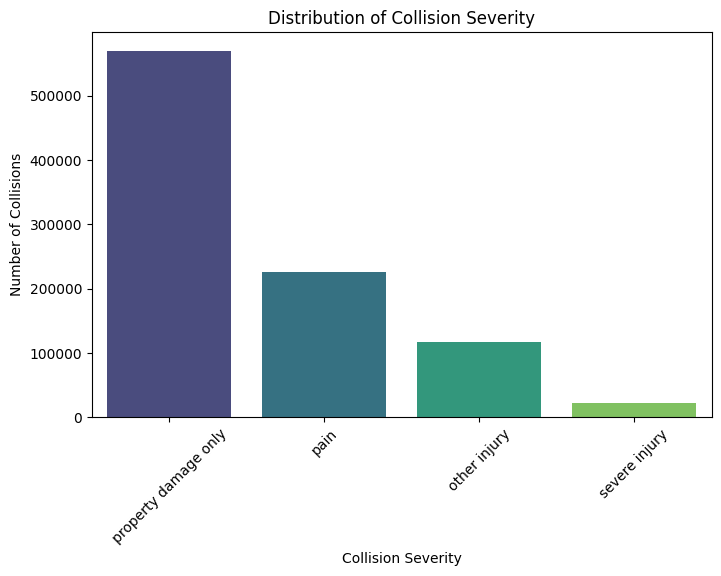

In [ ]:
# Univariate Analysis

# Collision Severity Distribution

severity_dist = (
    final_df
    .groupBy("collision_severity")
    .count()
)

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas

severity_pd = severity_dist.toPandas()
severity_pd


# Plot
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=severity_pd,
    x="collision_severity",
    y="count",
    hue="collision_severity",
    palette="viridis",
)
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")
plt.title("Distribution of Collision Severity")
plt.xticks(rotation=45)
plt.show()


#Most collisions fall under lower‑severity categories, while severe and fatal collisions occur far less frequently.
#As in real life, high‑severity accidents are rare but critically important.

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

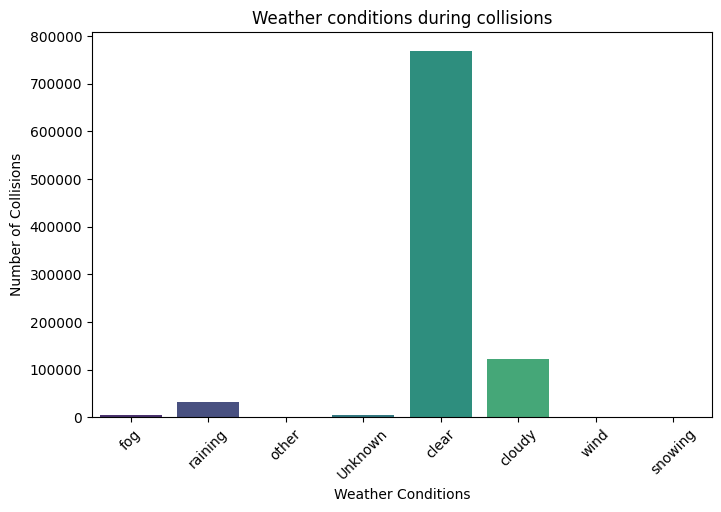

In [ ]:
# Weather Conditions During Collisions
weather_dist = (
    final_df
    .groupBy("weather_1")
    .count()
)
# Convert to Pandas
weather_pd = weather_dist.toPandas()
weather_pd

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=weather_pd,
    x="weather_1",
    y="count",
    hue="weather_1",
    palette="viridis",
)
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Collisions")
plt.title("Weather conditions during collisions")
plt.xticks(rotation=45)
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

Before cleaning victims table:  963933
After cleaning victims table:  925071
+-------+------------------+
|summary|        victim_age|
+-------+------------------+
|  count|            925071|
|   mean| 31.32092996105164|
| stddev|19.306756744458173|
|    min|               1.0|
|    25%|              17.0|
|    50%|              27.0|
|    75%|              45.0|
|    max|              99.0|
+-------+------------------+



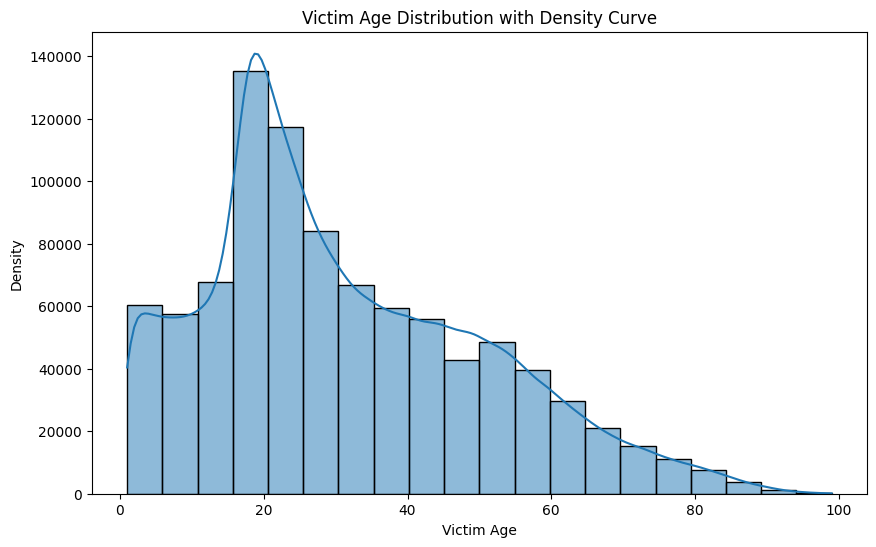

In [ ]:
# Distribution of Victim Ages

#Cleaning victim age column
victims_df_clean = victims_df.filter(
    (F.col("victim_age").isNotNull()) &
    (F.col("victim_age") > 0) &
    (F.col("victim_age") < 100)
)

print("Before cleaning victims table: ",victims_df.count())
print("After cleaning victims table: ",victims_df_clean.count())

#univariate Analysis
victims_df_clean.select("victim_age").summary().show()

# Convert to Pandas
victims_pd = victims_df_clean.toPandas()

# Plot

plt.figure(figsize=(10, 6))
sns.histplot(
    victims_pd["victim_age"],
    bins=20,
    kde=True
)
plt.title("Victim Age Distribution with Density Curve")
plt.xlabel("Victim Age")
plt.ylabel("Density")
plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

+--------------------+-----------------+-------------------------+--------------------------+
|  collision_severity|total_victims_sum|avg_victims_per_collision|max_victims_in_a_collision|
+--------------------+-----------------+-------------------------+--------------------------+
|property damage only|                0|                      0.0|                         0|
|                pain|           310030|                     1.37|                        20|
|        other injury|           176523|                     1.51|                        23|
|       severe injury|            35874|                     1.62|                        27|
+--------------------+-----------------+-------------------------+--------------------------+



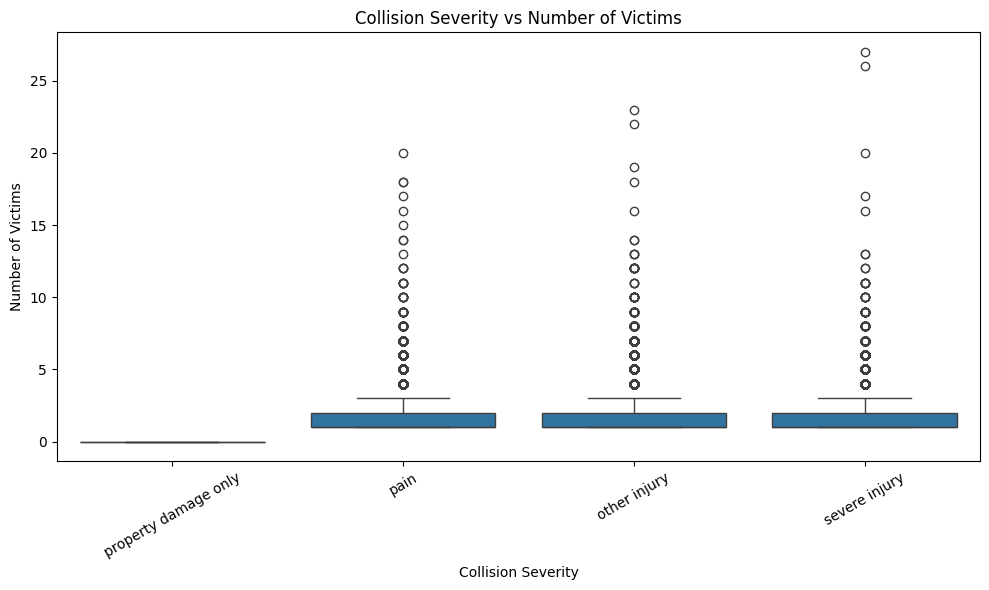

In [ ]:
# Bivariate Analysis
final_df = final_df.withColumn(
    "total_victims",
    F.coalesce(F.col("killed_victims"), F.lit(0)) +
    F.coalesce(F.col("injured_victims"), F.lit(0))
)

collisions_victims_df = final_df.select(
    "collision_severity",
    "killed_victims",
    "injured_victims",
    "total_victims"
)

# Collision Severity vs. Number of Victims

victims_by_severity_table = (
    collisions_victims_df
    .groupBy("collision_severity")
    .agg(
        F.sum("total_victims").alias("total_victims_sum"),
        F.round(F.avg("total_victims"), 2).alias("avg_victims_per_collision"),
        F.max("total_victims").alias("max_victims_in_a_collision")
    ))

victims_by_severity_table.show(20)


# Convert to Pandas
collisions_victims_pd = collisions_victims_df.toPandas()


# Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=collisions_victims_pd,
    x="collision_severity",
    y="total_victims"
)

plt.title("Collision Severity vs Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Victims")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#A box plot is the most suitable visualization to study the relationship between collision severity and the number of victims,
#as it effectively compares the distribution of victim counts across different severity categories.

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

collision_severity  other injury      pain  property damage only  \
weather_1                                                          
Unknown                    560.0    1193.0                2794.0   
clear                    97808.0  187202.0              466004.0   
cloudy                   14149.0   28847.0               76527.0   
fog                        517.0     754.0                2490.0   
other                       82.0     178.0                 797.0   
raining                   3336.0    7961.0               20419.0   
snowing                    148.0     220.0                 981.0   
wind                        54.0      89.0                 233.0   

collision_severity  severe injury  
weather_1                          
Unknown                      77.0  
clear                     18666.0  
cloudy                     2572.0  
fog                         140.0  
other                        24.0  
raining                     621.0  
snowing                      21

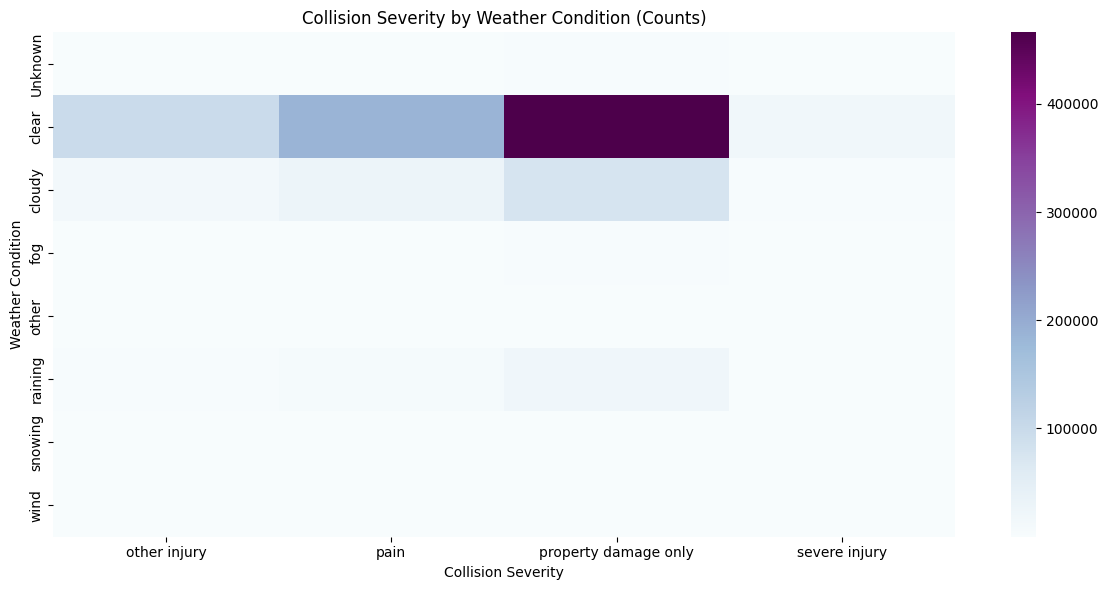

In [ ]:
# Weather vs. Collision Severity

ws_counts = (
    final_df
    .groupBy("weather_1", "collision_severity")
    .count()
)

# Convert to Pandas

ws_pd = ws_counts.toPandas()

#pivot_table() reshapes long (row‑wise) data into a matrix (cross‑tab)
#This conversion is required to generate Heat Maps
pivot_counts = ws_pd.pivot_table(
    index="weather_1",
    columns="collision_severity",
    values="count",
    fill_value=0
)

print(pivot_counts)

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_counts, cmap="BuPu")
plt.title("Collision Severity by Weather Condition (Counts)")
plt.xlabel("Collision Severity")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.show()

#“The heatmap shows that most collisions occur under the most frequent weather categories (typically clear/normal conditions),
#as they provide high driving exposure.
#Property damage only is the most frequent severity across weather
#Cloudy is the next notable contributor after clear



##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

In [ ]:
final_df.filter(F.col("lighting")=="").count()

0

In [ ]:
# Lighting Conditions vs. Collision Severity
ls_counts = (
    final_df
    .groupBy("lighting", "collision_severity")
    .count()
)

ls_counts.show(5)
print("Count of Rows:", ls_counts.count())


# Convert to Pandas
ls_pd = ls_counts.toPandas()

# Pivot to matrix: rows = lighting, columns = severity, values = counts
pivot_counts = ls_pd.pivot_table(
    index="lighting",
    columns="collision_severity",
    values="count",
    fill_value=0
)


pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

pivot_counts
pivot_pct.round(2)

+--------------------+--------------------+------+
|            lighting|  collision_severity| count|
+--------------------+--------------------+------+
|            daylight|property damage only|373991|
|dark with street ...|                pain| 42868|
|            daylight|                pain|161988|
|dark with no stre...|                pain| 12085|
|        dusk or dawn|property damage only| 19716|
+--------------------+--------------------+------+
only showing top 5 rows
Count of Rows: 24


collision_severity,other injury,pain,property damage only,severe injury
lighting,,,,
Unknown,10.95,23.33,64.33,1.40
dark with no street lights,14.33,16.19,65.13,4.35
dark with street lights,12.11,21.89,63.03,2.97
dark with street lights not functioning,12.78,21.83,61.93,3.45
daylight,12.36,25.91,59.81,1.92
dusk or dawn,12.71,24.14,60.40,2.74


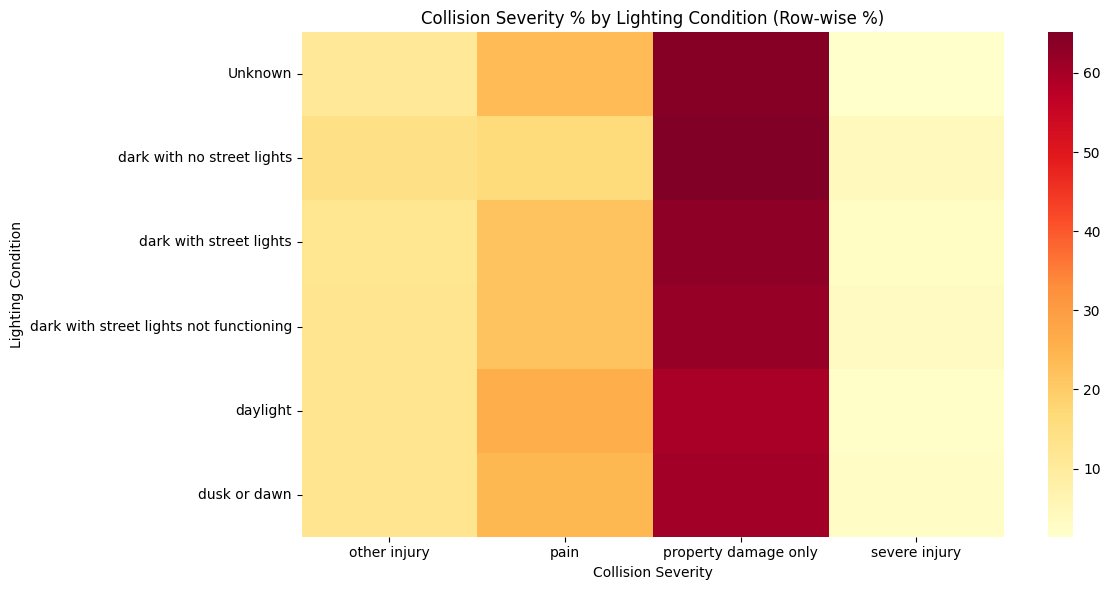

In [ ]:
# Plot

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_pct, cmap="YlOrRd")
plt.title("Collision Severity % by Lighting Condition (Row-wise %)")
plt.xlabel("Collision Severity")
plt.ylabel("Lighting Condition")
plt.tight_layout()
plt.show()


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

+-----------+---------+------+
|weekday_num|weekday  |count |
+-----------+---------+------+
|1          |Sunday   |109060|
|2          |Monday   |131280|
|3          |Tuesday  |136931|
|4          |Wednesday|137234|
|5          |Thursday |138648|
|6          |Friday   |154483|
|7          |Saturday |127842|
+-----------+---------+------+

+-----------+---------+------+----------+
|weekday_num|weekday  |count |percentage|
+-----------+---------+------+----------+
|1          |Sunday   |109060|11.66     |
|2          |Monday   |131280|14.03     |
|3          |Tuesday  |136931|14.64     |
|4          |Wednesday|137234|14.67     |
|5          |Thursday |138648|14.82     |
|6          |Friday   |154483|16.51     |
|7          |Saturday |127842|13.67     |
+-----------+---------+------+----------+



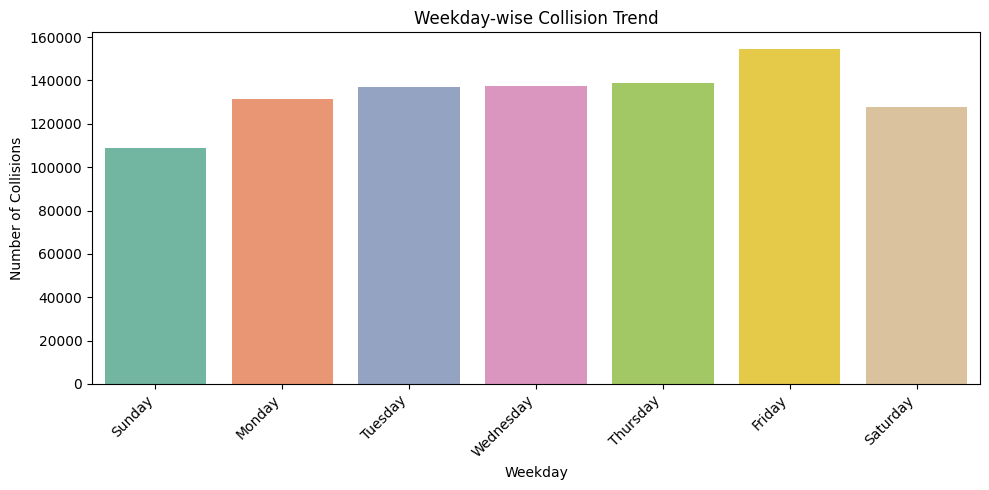

In [ ]:
# Extract the weekday

df_weekday = (final_df
    .withColumn("weekday_num", F.dayofweek("collision_date"))  # 1=Sun ... 7=Sat
    .withColumn("weekday", F.date_format("collision_date", "EEEE"))  # Monday, Tuesday...
)

#Weekday wise Collision Counts
weekday_trend = (df_weekday
    .groupBy("weekday_num", "weekday")
    .count()
    .orderBy("weekday_num")
)

weekday_trend.show(truncate=False)

#Percentage Share of Collisions
total_collisions = df_weekday.count()

weekday_trend_pct = (weekday_trend
    .withColumn("percentage", F.round(F.col("count") * 100 / F.lit(total_collisions), 2))
)

weekday_trend_pct.show(truncate=False)

#Convert to Pandas
weekday_pd = weekday_trend_pct.toPandas()
weekday_pd

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=weekday_pd,
    x="weekday",
    y="count",
    hue="weekday",
    palette="Set2",
    legend=False
)
plt.title("Weekday-wise Collision Trend")
plt.xlabel("Weekday")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

+---------------+---------------+
|county_location|collision_count|
+---------------+---------------+
|los angeles    |284027         |
|orange         |72025          |
|san bernardino |56725          |
|san diego      |53084          |
|riverside      |48667          |
|alameda        |46502          |
|sacramento     |40489          |
|santa clara    |34102          |
|contra costa   |21458          |
|san joaquin    |20612          |
|ventura        |20227          |
|kern           |19345          |
|fresno         |17435          |
|san mateo      |16698          |
|stanislaus     |14290          |
+---------------+---------------+
only showing top 15 rows


/tmp/ipykernel_692/1191262351.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


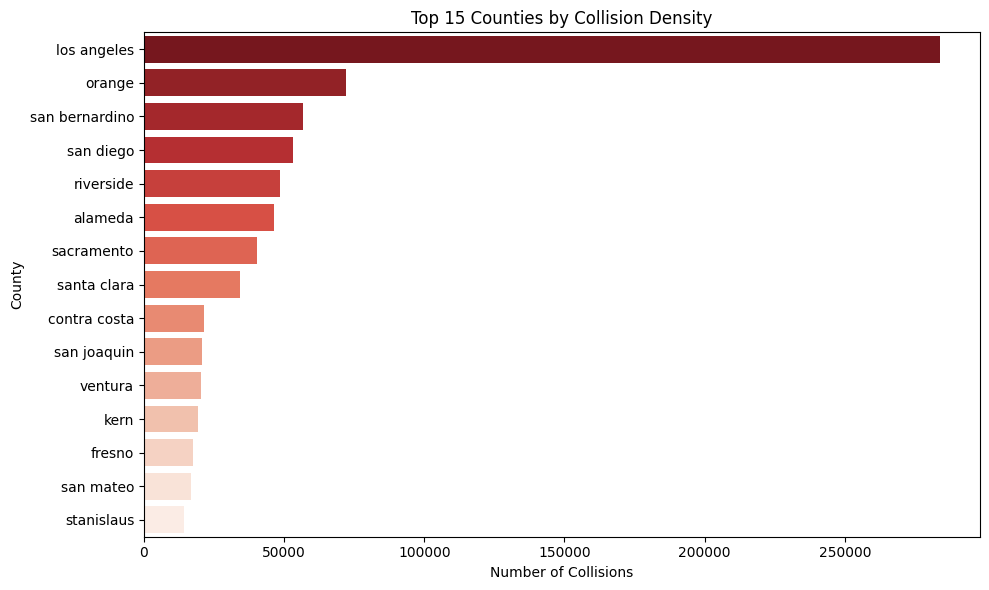

In [ ]:
# Spatial Analysis

#final_df.select("county_location").distinct().show()

county_density = (
    final_df
    .groupBy("county_location")
    .count()
    .withColumnRenamed("count", "collision_count")
    .orderBy(F.col("collision_count").desc())
)

county_density.show(15, truncate=False)

# Collision Density by County

#Convert to Pandas
county_pd = county_density.toPandas()

# Plot the map
plt.figure(figsize=(10, 6))
sns.barplot(
    data=county_pd.head(15),
    x="collision_count",
    y="county_location",
    palette="Reds_r"
)

plt.title("Top 15 Counties by Collision Density")
plt.xlabel("Number of Collisions")
plt.ylabel("County")
plt.tight_layout()
plt.show()


##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

In [ ]:
# Scatter Plot of Collision Locations

geo_df = (
    final_df
    .select("latitude", "longitude")
    .filter(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
)


# Convert PySpark DataFrame to Pandas, handling potential missing values
geo_pd = geo_df.toPandas()

# Convert to numeric (if needed) and handle invalid data
import pandas as pd

geo_pd["latitude"] = pd.to_numeric(geo_pd["latitude"], errors="coerce")
geo_pd["longitude"] = pd.to_numeric(geo_pd["longitude"], errors="coerce")

# Drop rows that became NaN after conversion
geo_pd = geo_pd.dropna(subset=["latitude", "longitude"])

print("Rows after numeric conversion & cleaning:", len(geo_pd))

Rows after numeric conversion & cleaning: 266742


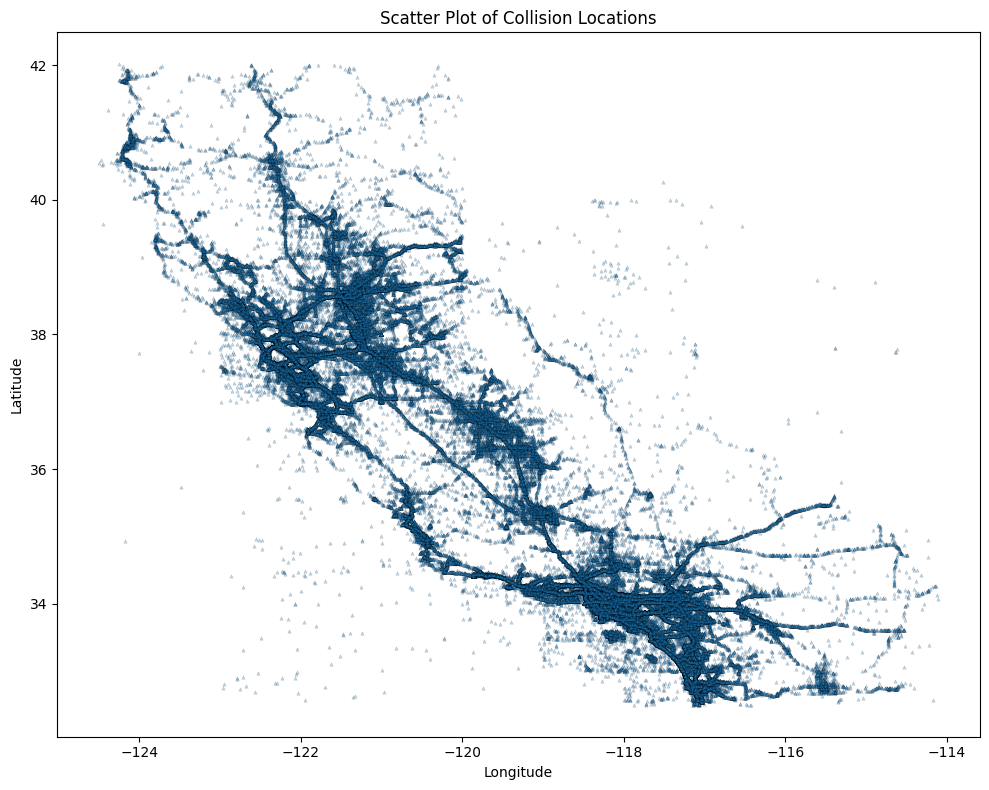

In [ ]:
# Plot the scatter plot

plt.figure(figsize=(10, 8))
plt.scatter(
    geo_pd["longitude"],
    geo_pd["latitude"],
    s=6,          # small point size for dense plots
    alpha=0.3,     # transparency helps with overlap
    marker = '^',
    edgecolors="black",
    linewidths=0.2

)

plt.title("Scatter Plot of Collision Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [ ]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date
df_time = final_df

df_time = df_time.withColumn("year", F.year("collision_date"))
df_time = df_time.withColumn("month_num", F.month("collision_date"))
df_time.printSchema()


total_collisions = df_time.count()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: integer (nullable = false)
 |-- officer_id: string (nullable = false)
 |-- reporting_district: string (nullable = false)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = false)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = false)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = false)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = false)
 |-- intersection: integer (nullable = false)
 |-- weather_1: string (nullable = false)
 |-- state_highway_indicator: integer (nullable = false)
 |-- caltrans_district: double (nullable = false)
 |-- state_route: double (nullable = fa

Q: Analyze yearly, monthly and hourly trends in collisions.

+----+---------------+----+
|year|collision_count| pct|
+----+---------------+----+
|2001|          51893|5.55|
|2002|          53434|5.71|
|2003|          53605|5.73|
|2004|          53703|5.74|
|2005|          53074|5.67|
|2006|          49642|5.31|
|2007|          49560| 5.3|
|2008|          44882| 4.8|
|2009|          42413|4.53|
|2010|          41320|4.42|
|2011|          40092|4.29|
|2012|          39689|4.24|
|2013|          38234|4.09|
|2014|          39702|4.24|
|2015|          43367|4.64|
|2016|          49167|5.26|
|2017|          48408|5.17|
|2018|          47951|5.13|
|2019|          46126|4.93|
|2020|          36018|3.85|
|2021|          13198|1.41|
+----+---------------+----+



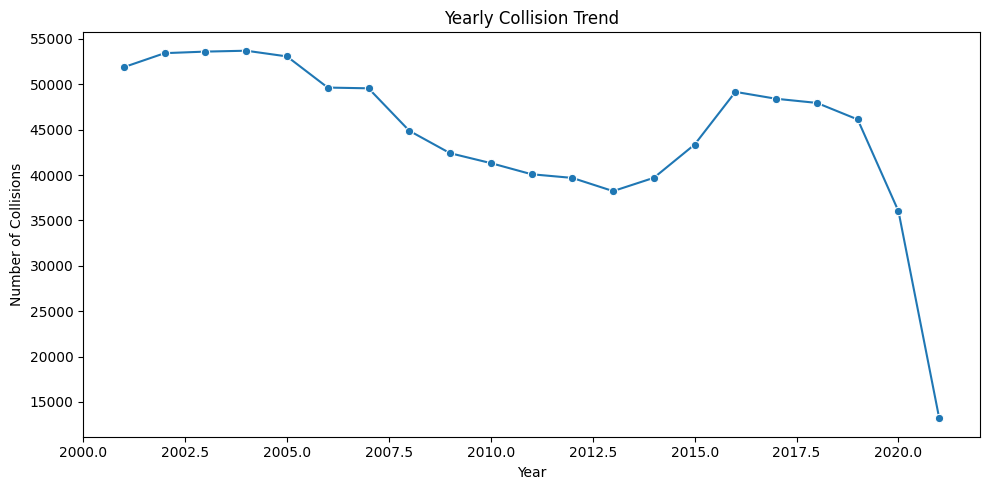

In [ ]:
# Yearly Trend of Collisions

yearly_trend = (
    df_time
    .groupBy("year")
    .count()
    .withColumnRenamed("count", "collision_count")
    .orderBy("year")
)

yearly_trend_pct = yearly_trend.withColumn(
    "pct", F.round(F.col("collision_count") * 100 / F.lit(total_collisions), 2)
)

yearly_trend_pct.show(21)

# Plot
yearly_pd = yearly_trend.toPandas()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_pd, x="year", y="collision_count", marker="o")
plt.title("Yearly Collision Trend")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.tight_layout()
plt.show()

In [ ]:
# Monthly Trend of Collisions

monthly_trend = (
    df_time
    .withColumn("month", F.date_format("collision_date", "MMMM"))
    .groupBy("month_num", "month")
    .count()
    .withColumnRenamed("count", "collision_count")
    .orderBy("month_num")
)

monthly_trend_pct = monthly_trend.withColumn(
    "pct", F.round(F.col("collision_count") * 100 / F.lit(total_collisions), 2)
)

monthly_trend_pct.show(truncate=False)




+---------+---------+---------------+----+
|month_num|month    |collision_count|pct |
+---------+---------+---------------+----+
|1        |January  |78300          |8.37|
|2        |February |75754          |8.1 |
|3        |March    |82133          |8.78|
|4        |April    |76180          |8.14|
|5        |May      |78926          |8.44|
|6        |June     |74734          |7.99|
|7        |July     |74763          |7.99|
|8        |August   |76943          |8.22|
|9        |September|76992          |8.23|
|10       |October  |83244          |8.9 |
|11       |November |78035          |8.34|
|12       |December |79474          |8.5 |
+---------+---------+---------------+----+



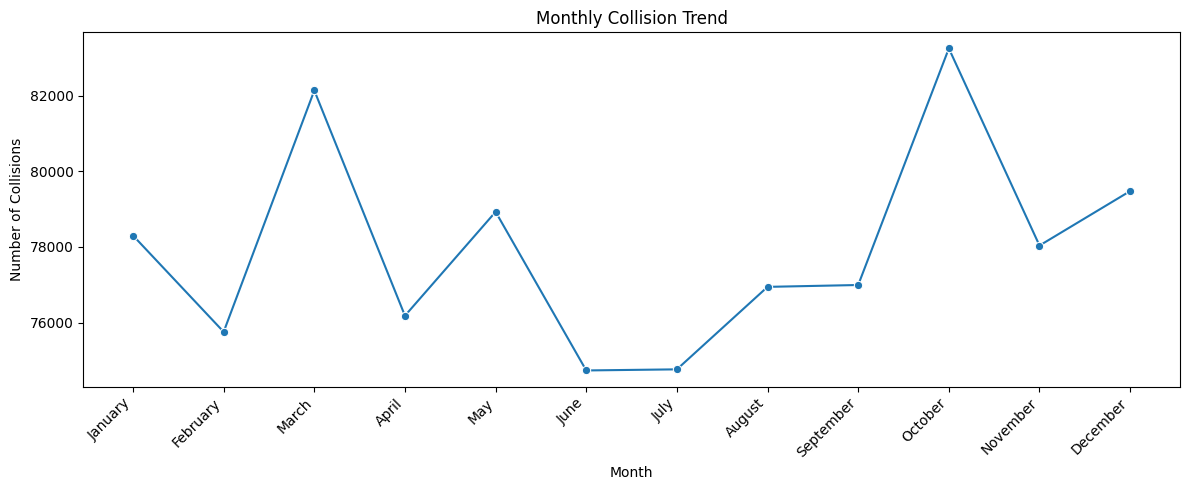

In [ ]:
# Plot

monthly_pd = monthly_trend.toPandas()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_pd, x="month", y="collision_count", marker="o")
plt.title("Monthly Collision Trend")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Hourly Trend of Collisions

hourly_trend = (
    df_time
    .withColumn("hour", F.hour("collision_time"))
    .groupBy("hour")
    .count()
    .withColumnRenamed("count", "collision_count")
    .orderBy("hour")
)

hourly_trend_pct = hourly_trend.withColumn(
    "pct", F.round(F.col("collision_count") * 100 / F.lit(total_collisions), 2)
)


hourly_trend_pct.show(truncate=False)

+----+---------------+----+
|hour|collision_count|pct |
+----+---------------+----+
|NULL|8084           |0.86|
|0   |18355          |1.96|
|1   |17563          |1.88|
|2   |17596          |1.88|
|3   |11943          |1.28|
|4   |10649          |1.14|
|5   |15280          |1.63|
|6   |25145          |2.69|
|7   |47457          |5.07|
|8   |48906          |5.23|
|9   |38576          |4.12|
|10  |39041          |4.17|
|11  |44718          |4.78|
|12  |51943          |5.55|
|13  |53205          |5.69|
|14  |60118          |6.43|
|15  |70819          |7.57|
|16  |67411          |7.21|
|17  |73236          |7.83|
|18  |58842          |6.29|
+----+---------------+----+
only showing top 20 rows


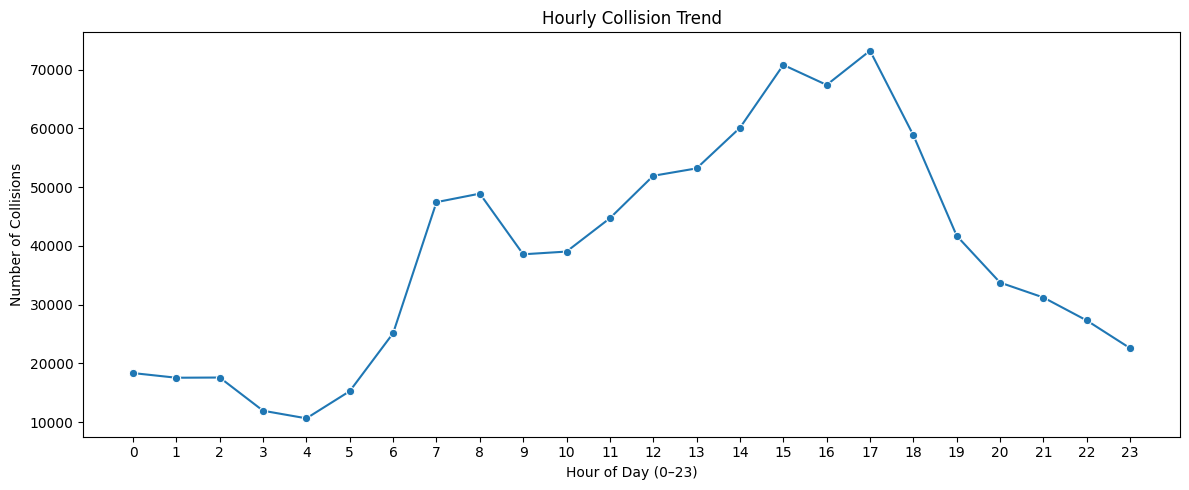

In [ ]:
# Plot

hourly_pd = hourly_trend.toPandas()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pd, x="hour", y="collision_count", marker="o")
plt.title("Hourly Collision Trend")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Collisions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [ ]:
# Query: Identify the top 5 counties with the most collisions


from pyspark.sql.functions import col, desc

top_5_counties = (
    final_df
    .groupBy("county_location")
    .count()
    .orderBy(desc("count"))
    .limit(5)
)

top_5_counties.show(truncate=False)

+---------------+------+
|county_location|count |
+---------------+------+
|los angeles    |284027|
|orange         |72025 |
|san bernardino |56725 |
|san diego      |53084 |
|riverside      |48667 |
+---------------+------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [ ]:
# Query: Find the month with the highest number of collisions

from pyspark.sql.functions import month, date_format, col, desc

month_with_max_collisions = (
    final_df
    .withColumn("month_num", month("collision_date"))
    .withColumn("month", date_format("collision_date", "MMMM"))
    .groupBy("month_num", "month")
    .count()
    .orderBy(desc("count"))
    .limit(1)
)

month_with_max_collisions.show(truncate=False)

+---------+-------+-----+
|month_num|month  |count|
+---------+-------+-----+
|10       |October|83244|
+---------+-------+-----+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [ ]:
# Query: Find the most common weather condition during collisions

most_common_weather = (
    final_df
    .filter(col("weather_1").isNotNull())
    .groupBy("weather_1")
    .count()
    .orderBy(desc("count"))
    .limit(1)
)

most_common_weather.show(truncate=False)


+---------+------+
|weather_1|count |
+---------+------+
|clear    |769680|
+---------+------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [ ]:
# Query: Determine the percentage of collisions that resulted in fatalities

from pyspark.sql.functions import col, count, sum as spark_sum, when, round

fatality_percentage = (
    final_df
    .agg(
        count("*").alias("total_collisions"),
        spark_sum(
            when(col("killed_victims") > 0, 1).otherwise(0)
        ).alias("fatal_collisions")
    )
    .withColumn(
 "fatality_percentage",
        round(
            (col("fatal_collisions") / col("total_collisions")) * 100, 2
        )
    )
)

fatality_percentage.select("fatality_percentage").show(truncate=False)

+-------------------+
|fatality_percentage|
+-------------------+
|0.0                |
+-------------------+



## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [ ]:
# Query: Find the most dangerous time of day for collisions
from pyspark.sql.functions import hour, col, desc

df_time = final_df.withColumn(
    "collision_time",
    F.to_timestamp("collision_time")
)

#Extract hour of day (0–23)
df_with_hour = df_time.withColumn(
    "hour_of_day",
    F.hour(F.col("collision_time"))
)

#Group by hour and count collisions
hourly_collision_counts = (
    df_with_hour
    .groupBy("hour_of_day")
    .count()
)

#Identify the most dangerous time of day
most_dangerous_time = (
    hourly_collision_counts
    .orderBy(F.desc("count"))
    .limit(1)
)

# Step 5: Display result
most_dangerous_time.show(truncate=False)



+-----------+-----+
|hour_of_day|count|
+-----------+-----+
|17         |73236|
+-----------+-----+



In [ ]:
final_df.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: integer (nullable = false)
 |-- officer_id: string (nullable = false)
 |-- reporting_district: string (nullable = false)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = false)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = false)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = false)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = false)
 |-- intersection: integer (nullable = false)
 |-- weather_1: string (nullable = false)
 |-- state_highway_indicator: integer (nullable = false)
 |-- caltrans_district: double (nullable = false)
 |-- state_route: double (nullable = fa

## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [ ]:
# Query: List the top 5 road types with the highest collision frequency


road_surface_counts = (
    final_df
    .groupBy("road_surface")
    .count()
    .orderBy(F.desc("count"))
    .limit(5)
    )

road_surface_counts.show(truncate=False)


+------------+------+
|road_surface|count |
+------------+------+
|dry         |845343|
|wet         |76820 |
|Unknown     |8137  |
|snowy       |4120  |
|slippery    |1048  |
+------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [ ]:
# Query: Find the top 3 lighting conditions that lead to the most collisions


top_3_lighting_conditions = (
    final_df
    .groupBy("lighting")
    .count()
    .orderBy(F.desc("count"))
    .limit(3)
)

top_3_lighting_conditions.show(truncate=False)

+--------------------------+------+
|lighting                  |count |
+--------------------------+------+
|daylight                  |625313|
|dark with street lights   |195834|
|dark with no street lights|74623 |
+--------------------------+------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [ ]:
# Final insights and recommendations

5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.

Insights -
1. Collision counts are concentrated in specific geographic hotspots (high‑density zones).
2. Peak collision times occur during 2PM - 6PM

Recommendations -
1. Infrastructure should be upgraded (road resurfacing, signage, lane markings) at high-collision locations.
2. Increase traffic monitoring and policing during peak accident hours
3. Improve junction design (roundabouts, protected turns) at locations with repeated collisions.


5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.

Insights -
1. Collision severity rises under poor lighting and adverse weather.

Recommendations -
1. Reduce Speed Limits in accident prone roads
2. Keep longer time duration for amber in traffic Signal
3. Upgrade to high‑performance LED street lighting in low‑visibility areas.
4. Fix the Potholes if any
5. Improve road drainage
6. Introduce Message signs in high risk zones


5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.

Insights -
Pedestrians, cyclists are impacted in: High‑density urban areas, Low‑lighting conditions, Peak traffic hours

Recommendations -
1. Mandate protected bike lanes and raised pedestrian crossings in collision  zones.
2. Extend pedestrian crossing signal times, especially near schools and hospitals.
3. Enforce lower speed limits in residential areas.



5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.

Insights -
Collision density maps display collision hotspots.
More number of collisions has happened in few co ordinates.

Recommendations -
1. Increase Monitoring and policing in high risk zones
2. Place sensors/Cameras to monitor the speed to avoid speeding related collisions
3. Introduce message signs in high risk zones to alert people

5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.

Insights -
1. Lighting condition correlates with collision frequency.
2. Weather and road surface condition influence severity more than frequency.
3. Poor visibility increases serious injuries.

Recommendations -
1. Improve street lights in high risk zones.
2. Integrate real‑time weather alerts into traffic management systems.
3. Improve road surface and apply anti skid surfacing in high risk zones

5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.

1. Develop predictive models using:
Location,Time of day, Weather, lighting, road surface, Historical collision density


2. Use models to:
Forecast emerging hotspots,
Reduce vehicle speed in possible collision hotspot,
Guide infrastructure investments


3. Integrate models with city traffic control systems for real‑time interventions.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>